In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")
print("Person 1 - EDA Notebook - HypeCheck Project")

All imports successful!
Person 1 - EDA Notebook - HypeCheck Project


In [2]:
# Load the dataset
df = pd.read_csv('../data/headlines.csv')

# Show basic info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (32000, 2)

First 5 rows:


,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1
3,"This Vine Of New York On ""Celebrity Big Brothe...",1
4,A Couple Did A Stunning Photo Shoot With Their...,1


In [3]:
# Check for missing values and duplicates
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nLabel distribution:")
print(df['clickbait'].value_counts())

Missing values:
headline     0
clickbait    0
dtype: int64

Duplicate rows: 0

Label distribution:
clickbait
0    16001
1    15999
Name: count, dtype: int64


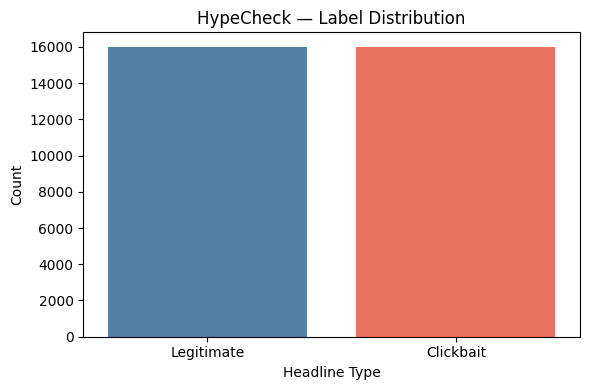

Chart saved!


In [4]:
# Plot label distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='clickbait', data=df, palette=['steelblue', 'tomato'])
plt.title('HypeCheck — Label Distribution')
plt.xticks([0, 1], ['Legitimate', 'Clickbait'])
plt.xlabel('Headline Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/label_dist.png')
plt.show()
print("Chart saved!")

Average headline length:
clickbait
0    51.853322
1    55.741046
Name: length, dtype: float64


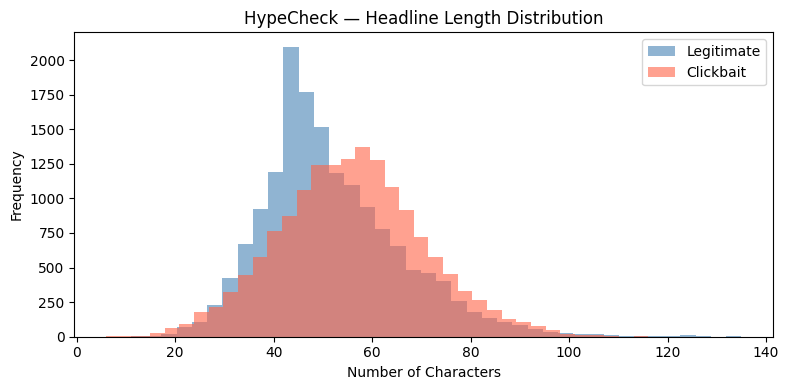

In [5]:
# Add a new column for headline length
df['length'] = df['headline'].apply(len)

print("Average headline length:")
print(df.groupby('clickbait')['length'].mean())

# Plot length distribution
plt.figure(figsize=(8, 4))
df[df['clickbait']==0]['length'].plot(kind='hist', alpha=0.6, bins=40, color='steelblue', label='Legitimate')
df[df['clickbait']==1]['length'].plot(kind='hist', alpha=0.6, bins=40, color='tomato', label='Clickbait')
plt.title('HypeCheck — Headline Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../data/length_dist.png')
plt.show()

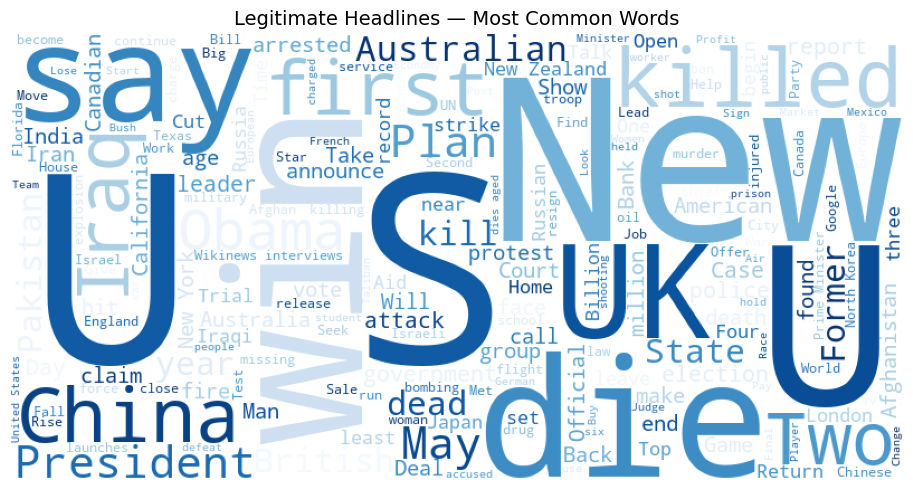

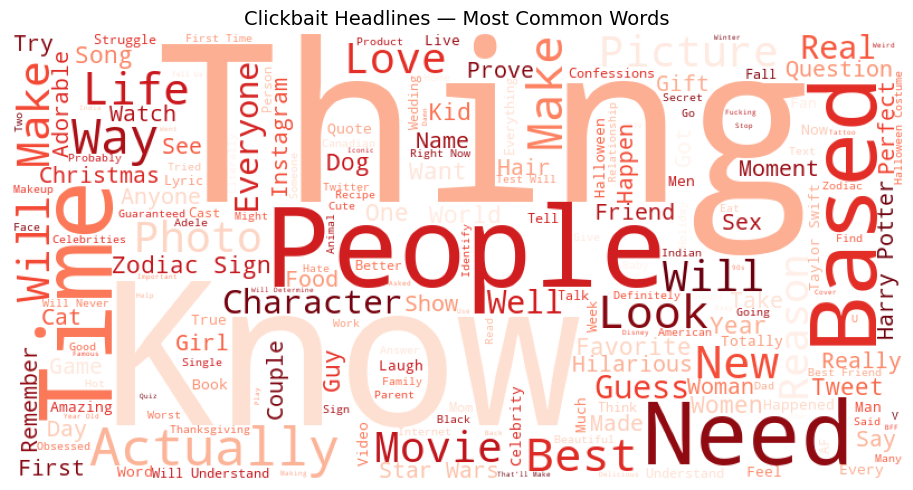

Both WordClouds saved!


In [6]:
# WordCloud for Legitimate headlines
legit_text = ' '.join(df[df['clickbait']==0]['headline'])
wc_legit = WordCloud(width=800, height=400, 
                     background_color='white',
                     colormap='Blues').generate(legit_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_legit)
plt.axis('off')
plt.title('Legitimate Headlines — Most Common Words', fontsize=14)
plt.tight_layout()
plt.savefig('../data/wc_legit.png')
plt.show()

# WordCloud for Clickbait headlines
clickbait_text = ' '.join(df[df['clickbait']==1]['headline'])
wc_clickbait = WordCloud(width=800, height=400, 
                          background_color='white',
                          colormap='Reds').generate(clickbait_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_clickbait)
plt.axis('off')
plt.title('Clickbait Headlines — Most Common Words', fontsize=14)
plt.tight_layout()
plt.savefig('../data/wc_clickbait.png')
plt.show()

print("Both WordClouds saved!")